# Mini-project 2: Conditional Variational auto-encoders (cvae_onehots)

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---
---

**Our notebook is structured as follows :**

1. **Introduction to auto-encoders, variational auto-encoders, and conditional variational auto-encoders.**
- Auto-encoders
- Variational auto-encoders
- Conditional variational auto-encoders

2. **The idea in non-convolutional CVAE, and why we don't do it the same way for CVAEs**
- Architectures to be tested
- Training these models
- Visualizing the models
- Validating hyperparameters: choice of hidden dimension.

3. **Training the models specifically for image generation**

5. **Conclusion**


---
---

## 1 Introduction to auto-encoders, variational auto-encoders, and conditional variational auto-encoders.

### 1.1 Auto-encoders
Auto-encoders (AE) are unsupervised learning models built on two architectural components that are trained together: The **encoder**, whose role is to reduce the dimension of the inputs through a funnel-shaped neural network, and the **decoder**, whose role is to turn the output of the encoder into an object with the same dimension as the encoder's input [1]. The objective of the learning procedure is that the data that enters the encoder should be similar to the data that exits the decoder. 

The state the data is found in between these two components is called the latent-state, and its role is to prevent overtraining of the model by forcing, through the reduction of dimension, a loss of information, so that the decoder cannot learn to exactly invert the transformations opperated by the encoder. Hence AEs can be seen as a generalization of principal component analysis (PCA), as the output of the encoder is a vector of smaller dimension, encoding the most vital information about the data. We can even note that AEs built on neural-networks with linear activation functions are mathematically equivalent to PCA [1]. 


### 1.2 Variational Auto-encoders (VAE)
**Variational Auto-encoders** are unsupervised learning model with the same overall architecture, except that the latent space is no longer a vector space of smaller dimension, but a space of random variables [1] [2]. This latent space is often parametrized with $(\mu_i)_i$ and $\log(\Sigma)$, and the space of random distributions that can be learnt is reduced to the set of $\mathcal N_d(\mu,\sigma^2)$, where $\mu\in\mathbb R^d$ and $\Sigma$ is a matrix in $\mathbb R^n\times\mathbb R^n$, often assumed to be diagonal. Thus in training, the VAE will learn how the distribution of the data can be encoded.

VAEs have another major plus compared to vanilla auto-encoders: given that in training the parameters for generating the data were learnt, the auto-encoder can now autonomosly generate data, as it only needs to simulate the random variable whose parameters were estimated in training. The VAE can even be trained with a supplementary KL-divergence term in the objective function, so that the latent representation of all individuals in the data resembles a realisation of a gaussian vextor. This makes the model better at data generation as the simulation of a gaussian vector would never land in a "void" of the latent space, as data decoded from voids in the latent space would generate bastardized data.

This can also then be used in data augmentation techniques, but also in image generation. However, this method does not allow us to generate specifically new data from a specific class.

### 1.3 Conditional variational Auto-encoders (CVAE)
**Conditional variational Auto-encoders**

The idea behind this method is that, in classification tasks, data from different classes are generated from diferent random distributions, and therefore learning these distributions conditionally on the class the data was generated from is akin to learning how to classify the inputs. This is then no longer an unsupervised method [3]. After training then we could use the decoder as a conditional data generator.  

Some examples of Conditional variational auto-encoders exist on the web, but most of them make are built purely on neural-networks with no convolutions. [citations] This is fine whenever we are not interested in image generation, but it is a well known fact [1] vanilla neural-networks are very bad at preserving the locality of information necessary to handle images. 

There are however a few [4] that do use convolutions.

In this report we therefore create a few architectures of CVAEs with convolutional encoders and decoders.

## 2. The idea in non-convolutional CVAE, and why we don't do it the same way for CVAEs

In this case, the idea is very simple. Take the architecture of a classical non-convolutional VAE, but concatenating to the input of the encoder the class label (with one-hot-encoding representation, for example). Similarly, in the decoder's input, concatenate to the latent vector the same label (with same representation, one-hot-encoding). This has been shown to work very efficiently.

Conceptually, this approach would not be satisying for convolutional CVAEs.

## 2.1 Architectures to be tested

We will test multiple architecures of convolutional CVAEs on the Fashion MNIST dataset, a dataset of Zalando articles. Each example is composed of a grayscale image (one channel) of size 28×28 pixels and a label. As in the classical MNIST dataset, Fashion MNIST is composed of 10 different clothing classes, labeled from 0 to 9. The dataset is composed of 70,000 examples, split into a training set of 60,000 examples and a test set of 10,000 elements.

In [3]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='../../data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='../../data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

We will be choosing as a loss function a cross entropy function with a KL-divergence term.

In [4]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD

### 2.1.1 Concatenation of the label as an integer, after the convolutional layer

In this section we chose a purposefully bad architecture. Indeed, we decide to concatenate to the output of the convolutional layers the label as it is given in the dataset (i.e as an integer). This means the encoder will behave as if the labeling was a numerical value, and not a class. This is a classical mistake in Machine Learning: the way in which a label is encoded before being entered into a model matters a lot.

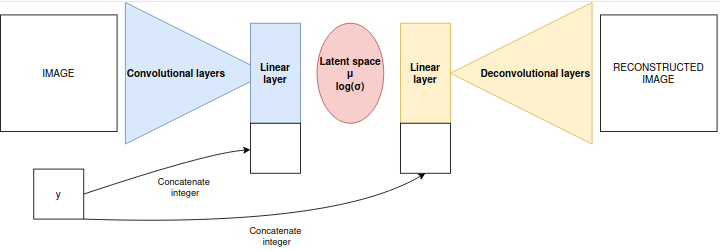

In [5]:

class ConditionalConvVAE_int_concatenation(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalConvVAE_int_concatenation, self).__init__()
        self.latent_dim = latent_dim
        self.nb_labels = 10

        # Convolutional layers of the encoder
        self.encoder_first_step = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

            
        self.linear = nn.Linear(128*4*4 + 1, 128*4*4 + 1)
        self.ReLU = nn.ReLU()
        
        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128 * 4 * 4 + 1, latent_dim) 
        self.fc_logvar = nn.Linear(128 * 4 * 4 + 1, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + 1, 128 * 4 * 4) 
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    
    def encode(self, x, label):
        x = self.encoder_first_step(x) #The convolutive steps
        x = x.view(-1, 128 * 4 * 4)
        
        #We need the label to be compatible with concatenation when there is batchig
        label = label.view(-1, 1).float()

        x = torch.cat([x, label], dim=1) #Concatenation

        x = self.linear(x)
        
        #z = x_bis.view(-1, 1 + 128 * 4 * 4) # Flatten the output of the convolutional layers
        z = self.ReLU(x.view(-1, 1 + 128 * 4 * 4) )
        mu = self.fc_mu(z)
        logvar = self.fc_logvar(z)
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, label):
        #We need the label to be compatible with concatenation when there is batchig
        label = label.view(-1, 1).float()

        #We need the label to be compatible with concatenation when there is batchig
        label = label.view(-1, 1).float()
        z = torch.cat([z, label], dim=1)
        x = self.fc_decode(z)
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x

    def forward(self, x, label):
        mu, logvar = self.encode(x,label)
        z = self.sample(mu, logvar)
        return self.decode(z, label), mu, logvar

    def generate_sample(self, label, num_samples=10):
        self.eval()
        with torch.no_grad():
            

            # Sample latent vectors
            z = torch.randn(num_samples, self.latent_dim, device=device)

            # Make label compatible with batching
            # label can be an int or tensor
            if isinstance(label, int):
                label = torch.tensor(label, device=device)

            label = label.view(1, 1).repeat(num_samples, 1).float()

            # Decode
            z = torch.cat([z, label], dim=1)
            x = self.fc_decode(z)
            x = x.view(-1, 128, 4, 4)
            samples = self.decoder(x)

            samples = samples.cpu().view(num_samples, 1, 28, 28)

            # Plot
            fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))
            if num_samples == 1:
                ax = [ax]
            for i in range(num_samples):
                ax[i].imshow(samples[i].squeeze(0), cmap='gray')
                ax[i].axis('off')
            plt.show()




### 2.1.2 Concatenation of the label as a one-hot-encoded vector, after the convolutional layer

Here, we proceed the same way, but with intelligent encoding of the label. As discussed above, a convolutional layer is better fit to detect forms and not values. Therefore we wish to feed the label into the encoder at a later step. Hence we concatenate the one-hot-encoding of the label to the output of the convolutional layers after flattening. Hence the information on the class of the data is directly transfered to the linear layer, which can nicely handle classes, thus bypassing the convolutional layer. The same logic applies to the decoder.

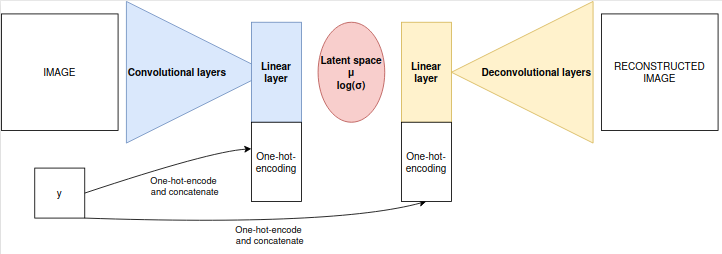

In [6]:

class ConditionalConvVAE_onehot_concatenation(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalConvVAE_onehot_concatenation, self).__init__()
        self.latent_dim = latent_dim
        self.nb_labels = 10

        # Convolutional layers of the encoder
        self.encoder_first_step = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

            
        self.linear = nn.Linear(128*4*4+self.nb_labels, 128*4*4+self.nb_labels)
        self.ReLU = nn.ReLU()
        
        # Fully connected layers for mean and log variaone_hotnce
        self.fc_mu = nn.Linear(self.nb_labels+128 * 4 * 4, latent_dim) 
        self.fc_logvar = nn.Linear(self.nb_labels+128 * 4 * 4, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + self.nb_labels, 128 * 4 * 4) 
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    
    def encode(self, x, label):
        x = self.encoder_first_step(x) #The convolutive steps
        x = x.view(-1, 128 * 4 * 4)
        
        #One hot encoding 
        one_hot_list = torch.nn.functional.one_hot(torch.arange(0, self.nb_labels)).to(device)
        one_hot_label = one_hot_list[label,:]

        if one_hot_label.dim() == 1:  # single integer label
            one_hot_label = one_hot_label.unsqueeze(0).repeat(x.size(0), 1)

        x = torch.cat([x, one_hot_label],  dim=1) #Concatenation

        x = self.linear(x)
        
        #z = x_bis.view(-1, 1 + 128 * 4 * 4) # Flatten the output of the convolutional layers
        z = self.ReLU(x.view(-1, self.nb_labels + 128 * 4 * 4) )
        mu = self.fc_mu(z)
        logvar = self.fc_logvar(z)
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, label):
        one_hot_list = torch.nn.functional.one_hot(torch.arange(0, self.nb_labels)).to(device)
        
        one_hot_label = one_hot_list[label,:]

        if one_hot_label.dim() == 1:  # single integer label
            one_hot_label = one_hot_label.unsqueeze(0).repeat(z.size(0), 1)
        
        z = torch.cat([z, one_hot_label], dim=1)
        x = self.fc_decode(z)
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x

    def forward(self, x, label):
        mu, logvar = self.encode(x,label)
        z = self.sample(mu, logvar)
        return self.decode(z, label), mu, logvar
    
    
    def generate_sample(self, label, num_samples=10):
        self.eval()
        with torch.no_grad():
            # Sample latent vectors
            z = torch.randn(num_samples, self.latent_dim).to(device)

            # Create one-hot label tensor
            one_hot_label = torch.nn.functional.one_hot(
                torch.tensor([label]*num_samples), num_classes=self.nb_labels
            ).float().to(device)

            # Decode
            x = self.fc_decode(torch.cat([z, one_hot_label], dim=1))
            x = x.view(-1, 128, 4, 4)
            samples = self.decoder(x)
            
            samples = samples.cpu().view(num_samples, 1, 28, 28)  # reshape for plotting

            # Plot
            fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))
            if num_samples == 1:
                ax = [ax]  # Make it indexable
            for i in range(num_samples):
                ax[i].imshow(samples[i].squeeze(0), cmap='gray')
                ax[i].axis('off')
            plt.show()


### 2.1.3 Channel learnt-encodings

Unlike in the two last architectures, we wish to pass the label into the convolutional layers. This poses an embedding problem, as there are multiple solutions to encode the class before feeding it into the convolutional layers. There are multiple options:

We conjectured that the best option would be one that did not alter the original image. Hence, in our model, we decide to encode the label as a second channel for the image. Hence we wish to learn a matrix encoding of the labels, that we then feed as a second channel to the convolutional layer in the encoder. For decoding, we concatenate, to the realisation of the random variable, the one hot enconding of the class. This means we have an asymmetric VAE.

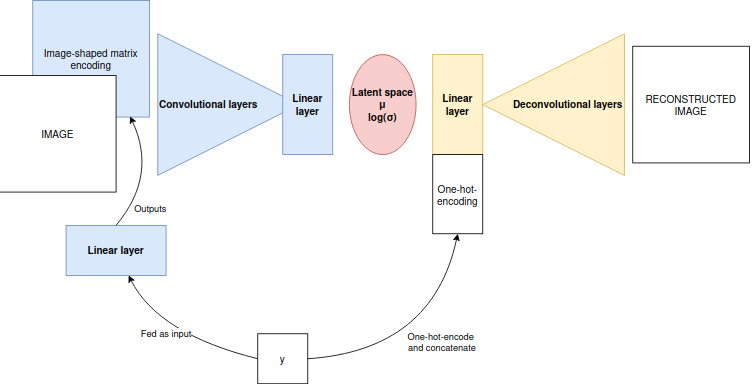

In [7]:
class ConditionalConvVAE_channel_concatenation(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalConvVAE_channel_concatenation, self).__init__()
        self.latent_dim = latent_dim
        self.nb_labels = 10

        # Mapping of one_hot to matrix(28*28)
        self.label_to_map = nn.Sequential(
            nn.Linear(self.nb_labels,512),
            nn.ReLU(),
            nn.Linear(512,28*28)
        ) 
        
        # Encoder
        self.encoder = nn.Sequential(

            # la dim de départ est (2*28*28)
            #      une matrice pour l'image
            #      une matrice pour le mapping des labels  
            
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

            
        self.linear = nn.Linear(128*4*4, 128*4*4)
        self.ReLU = nn.ReLU()


        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim) 
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + self.nb_labels, 128*4*4)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    

    def make_label_map(self,label) :
        one_hot_label = torch.nn.functional.one_hot(label, self.nb_labels).float()
        #print("one_hot_label = ", one_hot_label)
        label_vec = self.label_to_map(one_hot_label)
        label_matrix = label_vec.view(-1,1,28,28)
        return label_matrix



    def encode(self, x, label_map):
        x = torch.cat([x, label_map],  dim=1) #Concatenation (2*28*28)
        x = self.encoder(x)
        z = self.ReLU(x.view(-1, 128 * 4 * 4))
        mu = self.fc_mu(z)
        logvar = self.fc_logvar(z)
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, label):
        one_hot_label = F.one_hot(label, self.nb_labels).float()
        z = torch.cat([z, one_hot_label], dim=1)
        x = self.fc_decode(z)                  
        x = x.view(-1, 128, 4, 4)             
        x = self.decoder(x)
        return x
    

    def forward(self, x, label):
        label_map = self.make_label_map(label)
        mu, logvar = self.encode(x,label_map)
        z = self.sample(mu, logvar)
        return self.decode(z,label), mu, logvar
    
    def generate_sample(self, label, num_samples=10):
        self.eval()
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim).to(device)  # Sample latent vectors
            labels = torch.full((num_samples,), label, dtype=torch.long).to(device)
            samples = self.decode(z, labels)
            samples = samples.cpu().view(num_samples, 1, 28, 28)

            fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))
            if num_samples == 1:
                ax = [ax]

            for i in range(num_samples):
                ax[i].imshow(samples[i].squeeze(0), cmap='gray')
                ax[i].axis('off')
            plt.show()

    



## 2.2 Training these models

In [8]:
# Train the model for the given number of epochs
# At the end of each epoch, print the training loss
def train_model(model, train_loader, loss_function, epochs, device,optimizer):
    for epoch in range(1, epochs + 1):
        model.train() 
        running_loss = 0.0
        for batch_idx, (data, label) in enumerate(train_loader):

            data = data.to(device)
            label = label.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model.forward(data, label)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch}, Training loss: {epoch_loss:.4f}')

Here we create the models

In [9]:
# Hyperparameters
batch_size = 128
latent_dim = 2
learning_rate = 1e-3
epochs = 30
beta = 1

# Initialize the models

cvae_int = ConditionalConvVAE_int_concatenation(latent_dim=latent_dim)
cvae_int.to(device)

cvae_onehot = ConditionalConvVAE_onehot_concatenation(latent_dim=latent_dim)
cvae_onehot.to(device)

cvae_channel = ConditionalConvVAE_channel_concatenation(latent_dim=latent_dim)
cvae_channel.to(device)

optimizer_onehot = optim.Adam(cvae_onehot.parameters(), lr=learning_rate)
optimizer_channel = optim.Adam(cvae_channel.parameters(), lr=learning_rate)


and we can the train the integer concatenation

In [10]:
#The integer concatenation model
train_model(model = cvae_int, train_loader=train_loader, loss_function=loss_function, optimizer=optimizer_onehot , epochs=epochs, device=device)

Epoch 1, Training loss: 702.0827
Epoch 2, Training loss: 702.0793
Epoch 3, Training loss: 702.0644
Epoch 4, Training loss: 702.0590
Epoch 5, Training loss: 702.1082
Epoch 6, Training loss: 702.0524
Epoch 7, Training loss: 702.0893
Epoch 8, Training loss: 702.0820
Epoch 9, Training loss: 702.0582
Epoch 10, Training loss: 702.0748
Epoch 11, Training loss: 702.0649
Epoch 12, Training loss: 702.0617
Epoch 13, Training loss: 702.0628
Epoch 14, Training loss: 702.0658
Epoch 15, Training loss: 702.0733
Epoch 16, Training loss: 702.0840
Epoch 17, Training loss: 702.0893
Epoch 18, Training loss: 702.0797
Epoch 19, Training loss: 702.0664
Epoch 20, Training loss: 702.0624
Epoch 21, Training loss: 702.0878
Epoch 22, Training loss: 702.0693
Epoch 23, Training loss: 702.0839
Epoch 24, Training loss: 702.0725
Epoch 25, Training loss: 702.0430
Epoch 26, Training loss: 702.0880
Epoch 27, Training loss: 702.0816
Epoch 28, Training loss: 702.0714
Epoch 29, Training loss: 702.0713
Epoch 30, Training loss

In [11]:
#One_hot_encoder model
train_model(model = cvae_onehot, train_loader=train_loader, loss_function=loss_function, optimizer=optimizer_onehot , epochs=epochs, device=device)


Epoch 1, Training loss: 273.1296
Epoch 2, Training loss: 256.9172
Epoch 3, Training loss: 255.1297
Epoch 4, Training loss: 254.2324
Epoch 5, Training loss: 253.6714
Epoch 6, Training loss: 253.0421
Epoch 7, Training loss: 252.5727
Epoch 8, Training loss: 251.9963
Epoch 9, Training loss: 251.6343
Epoch 10, Training loss: 251.4002
Epoch 11, Training loss: 251.0103
Epoch 12, Training loss: 250.6532
Epoch 13, Training loss: 250.3808
Epoch 14, Training loss: 250.1591
Epoch 15, Training loss: 249.9277
Epoch 16, Training loss: 249.6403
Epoch 17, Training loss: 249.4269
Epoch 18, Training loss: 249.2566
Epoch 19, Training loss: 249.1257
Epoch 20, Training loss: 248.8852
Epoch 21, Training loss: 248.8235
Epoch 22, Training loss: 248.5886
Epoch 23, Training loss: 248.4681
Epoch 24, Training loss: 248.3286
Epoch 25, Training loss: 248.2026
Epoch 26, Training loss: 248.0598
Epoch 27, Training loss: 248.0625
Epoch 28, Training loss: 247.8428
Epoch 29, Training loss: 247.7201
Epoch 30, Training loss

In [12]:
#One_hot_encoder model
train_model(model = cvae_channel, train_loader=train_loader, loss_function=loss_function, optimizer=optimizer_channel , epochs=epochs, device=device)


Epoch 1, Training loss: 273.4317
Epoch 2, Training loss: 256.4041
Epoch 3, Training loss: 254.7830
Epoch 4, Training loss: 253.7274
Epoch 5, Training loss: 253.1442
Epoch 6, Training loss: 252.6304
Epoch 7, Training loss: 252.3247
Epoch 8, Training loss: 252.1820
Epoch 9, Training loss: 251.6327
Epoch 10, Training loss: 251.4759
Epoch 11, Training loss: 251.1746
Epoch 12, Training loss: 251.0325
Epoch 13, Training loss: 250.8089
Epoch 14, Training loss: 250.7397
Epoch 15, Training loss: 250.5014
Epoch 16, Training loss: 250.2713
Epoch 17, Training loss: 250.2312
Epoch 18, Training loss: 250.1411
Epoch 19, Training loss: 249.9392
Epoch 20, Training loss: 249.8272
Epoch 21, Training loss: 249.6715
Epoch 22, Training loss: 249.6060
Epoch 23, Training loss: 249.5271
Epoch 24, Training loss: 249.4363
Epoch 25, Training loss: 249.2398
Epoch 26, Training loss: 249.1865
Epoch 27, Training loss: 249.1477
Epoch 28, Training loss: 248.9969
Epoch 29, Training loss: 248.9273
Epoch 30, Training loss

## 2.3 Visualizing the models

We can visualize how the trained model performs by seeing how much of the original image is preserved by the model

In [13]:

def image_comparison(original_images, reconstructions, n_images=6):
    """Plots the original images and its reconstructions for comparison

    Args:
        original_image (torch.Tensor): The original images
        reconstructions (torch.Tensor): Reconstruction of the original images
    """
    fig, ax = plt.subplots(2, n_images, figsize=(20, 7))
    
    for i in range(n_images):
        # Plot original images
        ax[0, i].imshow(original_images[i], cmap='gray')
        ax[0, i].axis('off')
        ax[0, 0].set_title('Original')

        
        # Reconstructed images
        ax[1, i].imshow(reconstructions[i], cmap='gray')
        ax[1, i].axis('off')
        ax[1, 0].set_title('Reconstruction')
    
    plt.tight_layout()
    plt.show()



For the (purposefully horrible) integer enconding


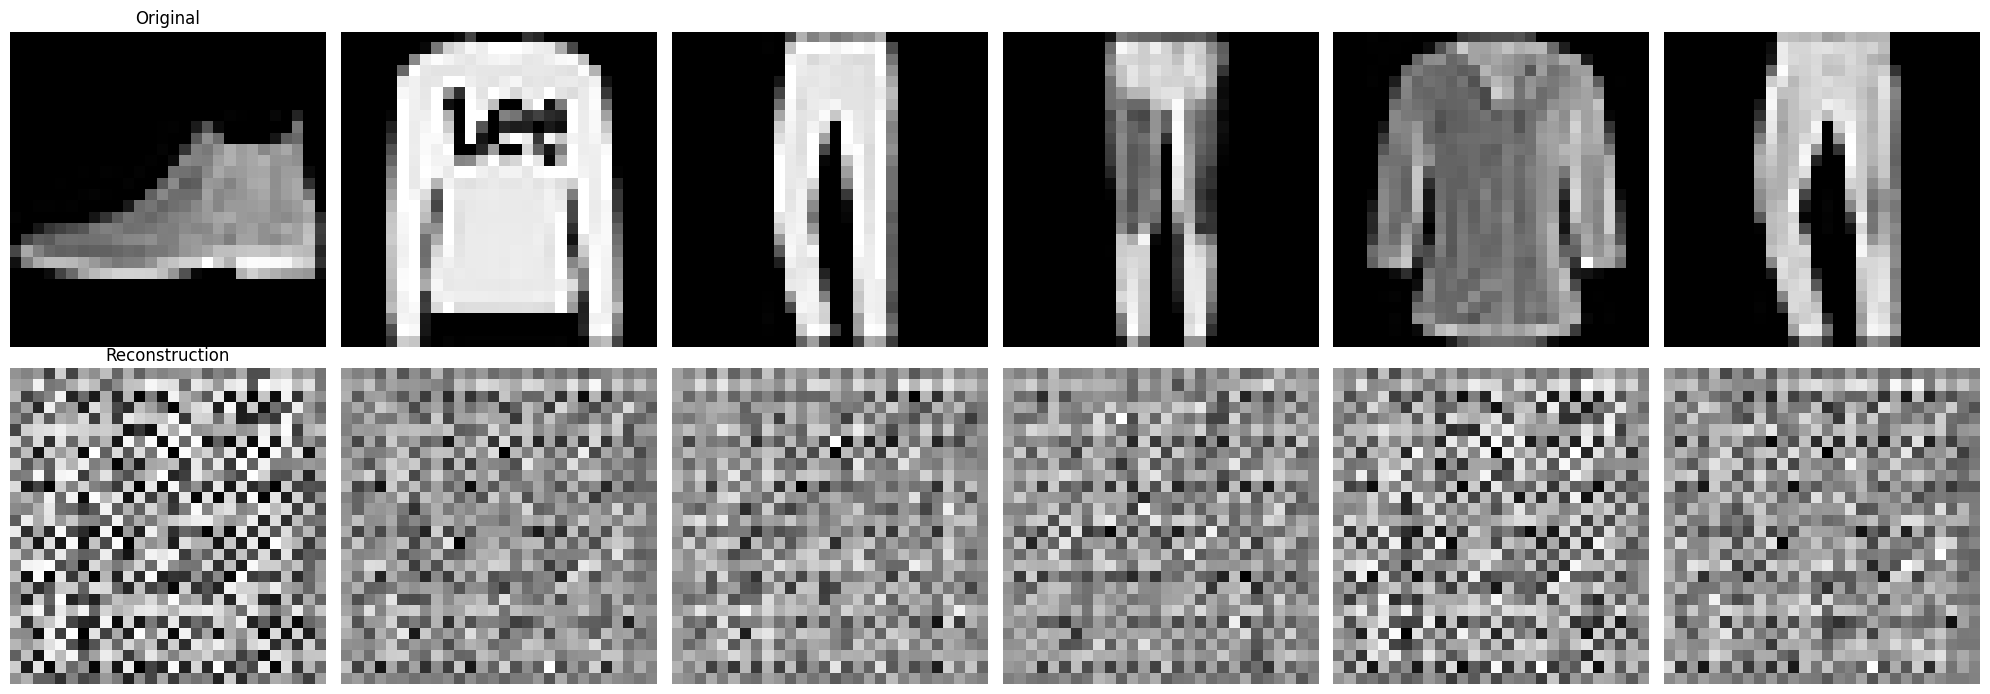

For the one-hot enconding


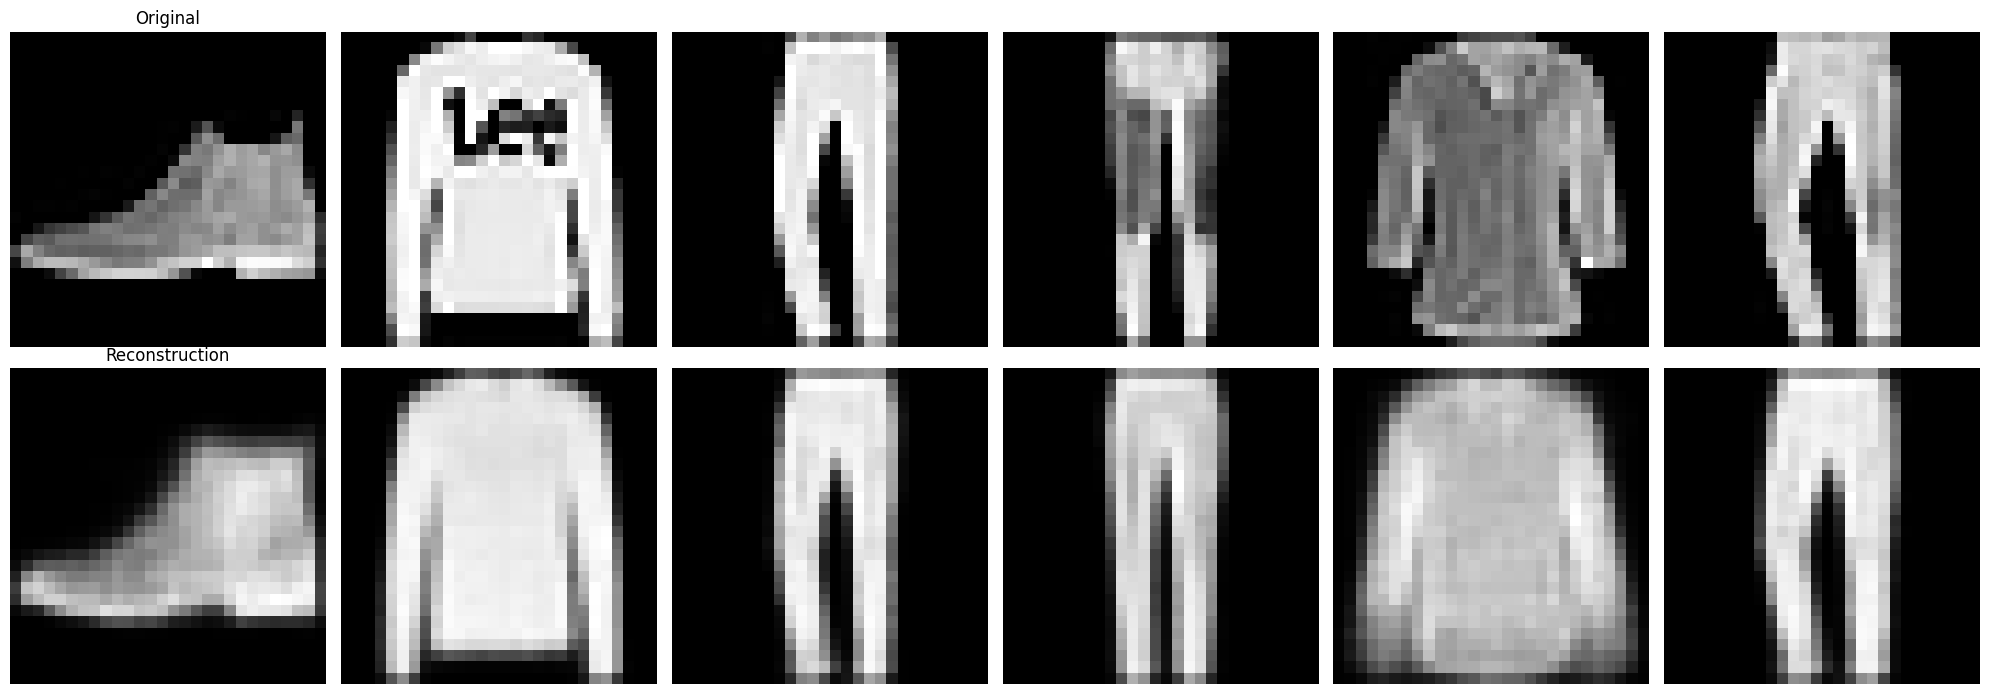

For the new channel enconding


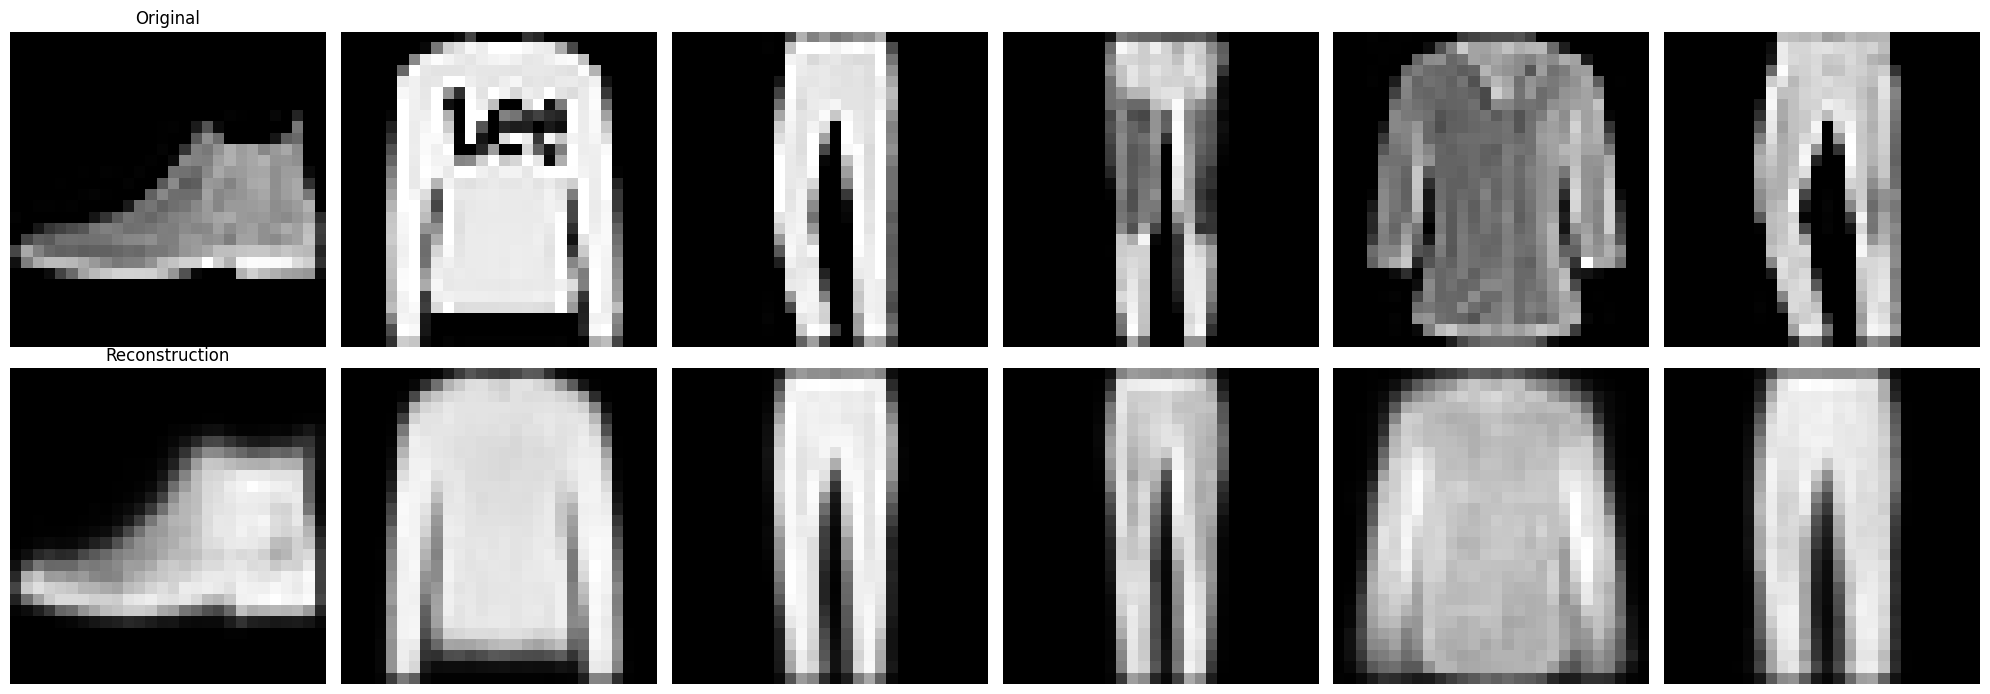

In [14]:
# Select a batch of images from the test dataset
random_images = next(iter(test_loader))

# Get the reconstructions of the selected images
recons_int,_,_ = cvae_int(random_images[0].to(device),random_images[1].to(device))
recons_onehot, _, _ = cvae_onehot(random_images[0].to(device),random_images[1].to(device))
recons_channel, _, _ = cvae_channel(random_images[0].to(device),random_images[1].to(device))

# Reshape the images for plotting
random_images = random_images[0].cpu().numpy().squeeze()
recons_int = recons_int.detach().cpu().numpy().squeeze()
recons_onehot = recons_onehot.detach().cpu().numpy().squeeze()
recons_channel = recons_channel.detach().cpu().numpy().squeeze()

# Plot the original images and their reconstructions
print("For the (purposefully horrible) integer enconding")
image_comparison(random_images, recons_int)
print("For the one-hot enconding")
image_comparison(random_images, recons_onehot)
print("For the new channel enconding")
image_comparison(random_images, recons_channel)

For the integer enconding, the results speak from themselves: the output of the decoder is undistinguishable from noise.

For the one-hot-encoding, these results are quite good, considering the latent dimension was only fixed at $2$

For (Paola)

And we can also see that the models can infact generate images conditionally on the label we ask them to input

for label 0 with the integer encoding model.


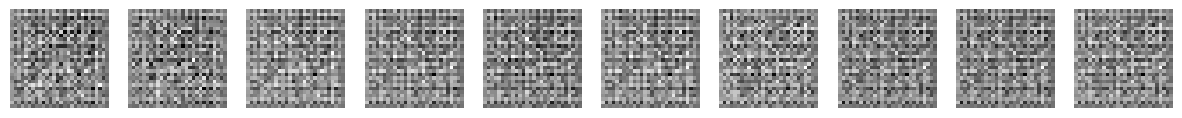

for label 0 with the onehot encoding.


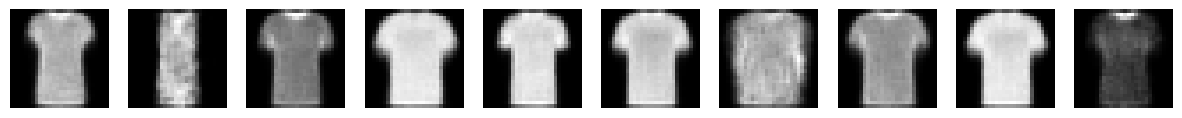

for label 0 with the new channel encoding.


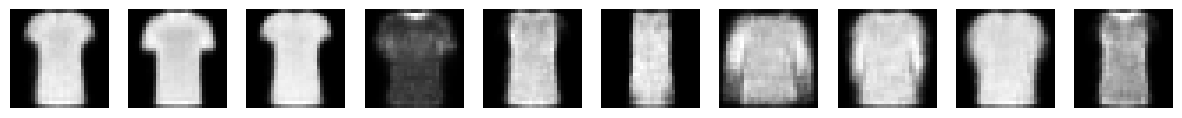

for label 1 with the integer encoding model.


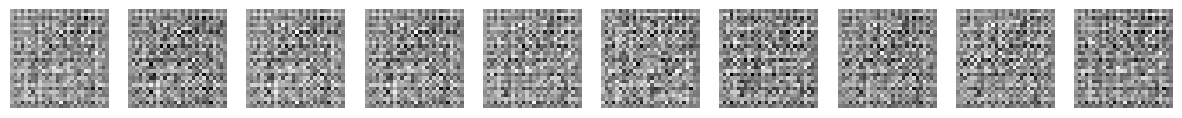

for label 1 with the onehot encoding.


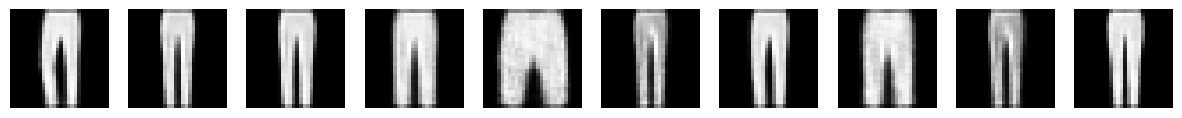

for label 1 with the new channel encoding.


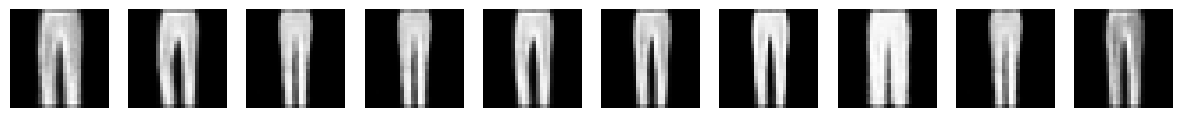

for label 2 with the integer encoding model.


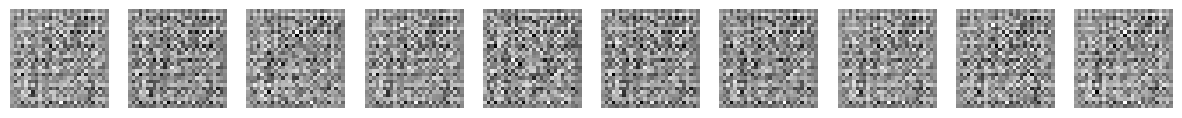

for label 2 with the onehot encoding.


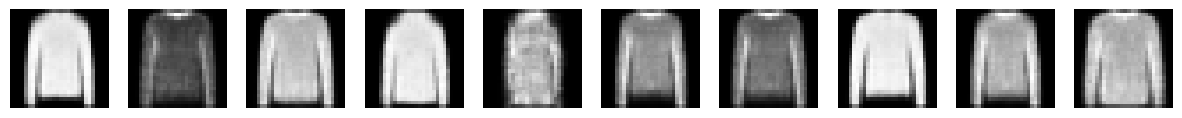

for label 2 with the new channel encoding.


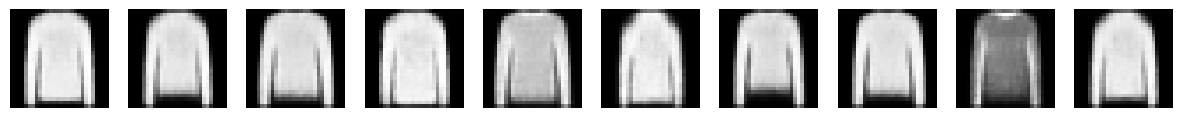

for label 3 with the integer encoding model.


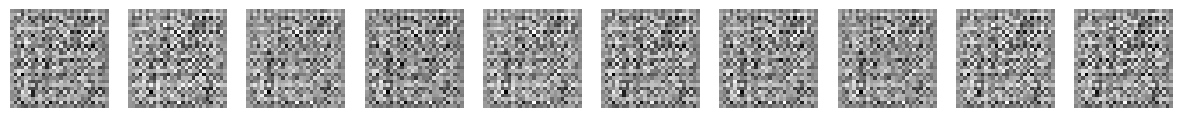

for label 3 with the onehot encoding.


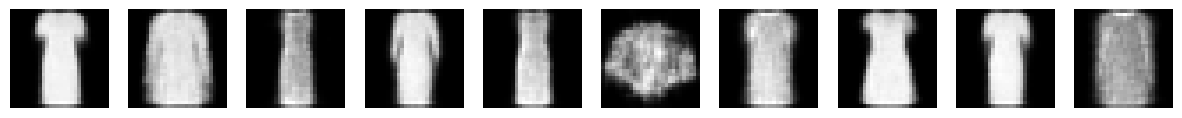

for label 3 with the new channel encoding.


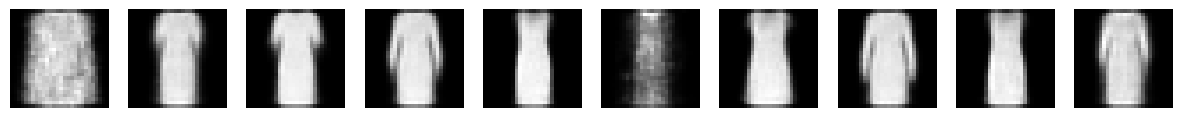

for label 4 with the integer encoding model.


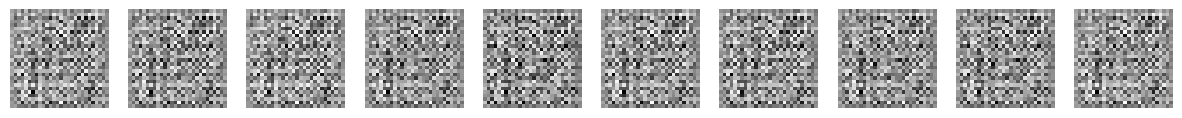

for label 4 with the onehot encoding.


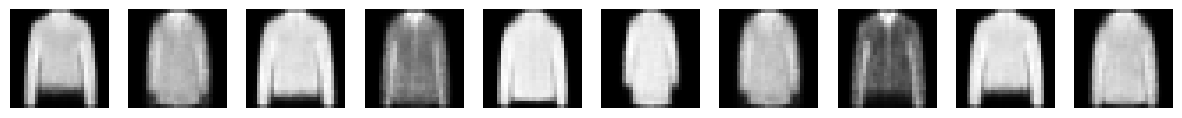

for label 4 with the new channel encoding.


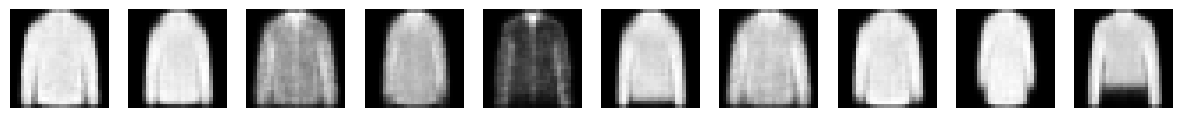

for label 5 with the integer encoding model.


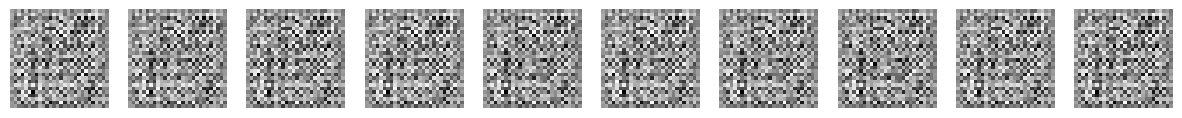

for label 5 with the onehot encoding.


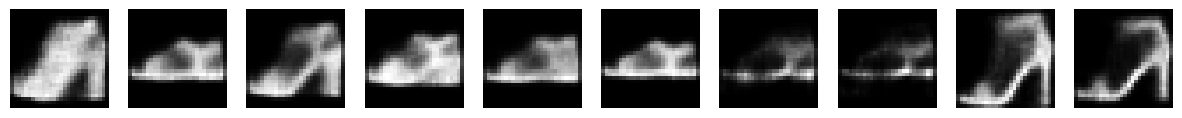

for label 5 with the new channel encoding.


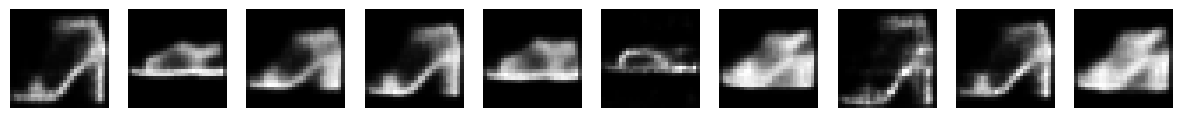

for label 6 with the integer encoding model.


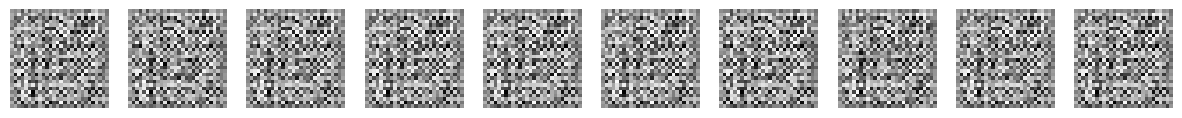

for label 6 with the onehot encoding.


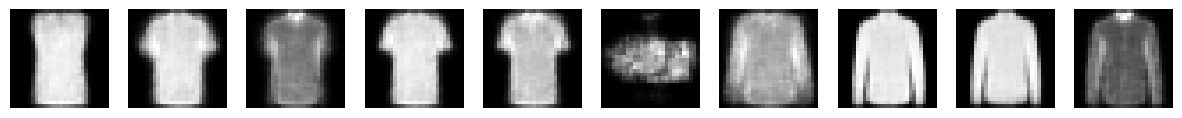

for label 6 with the new channel encoding.


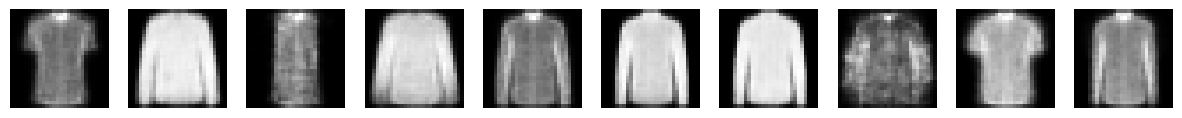

for label 7 with the integer encoding model.


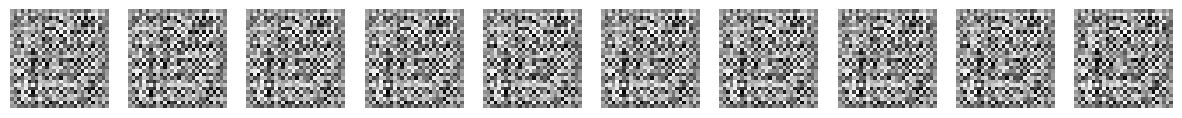

for label 7 with the onehot encoding.


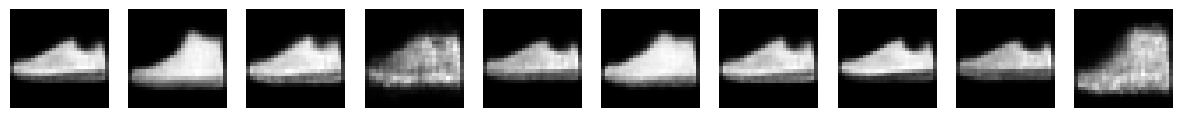

for label 7 with the new channel encoding.


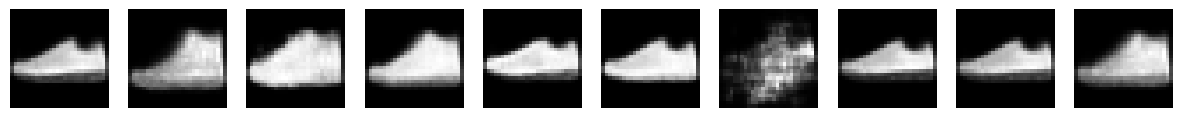

for label 8 with the integer encoding model.


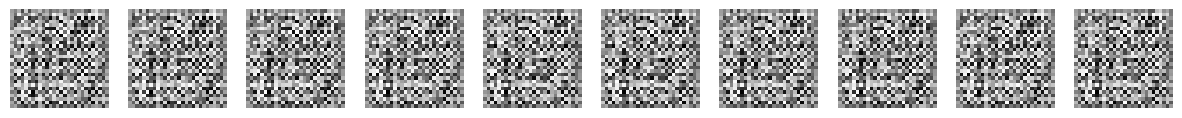

for label 8 with the onehot encoding.


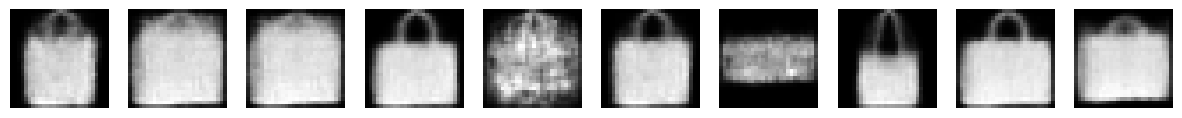

for label 8 with the new channel encoding.


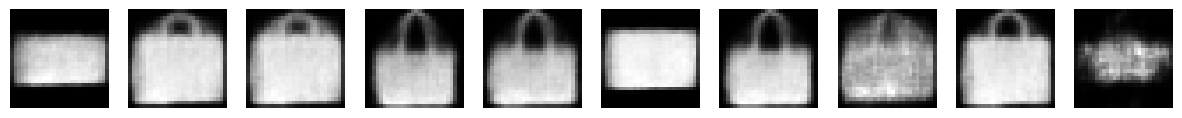

for label 9 with the integer encoding model.


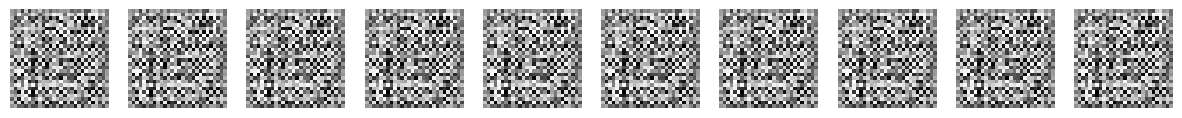

for label 9 with the onehot encoding.


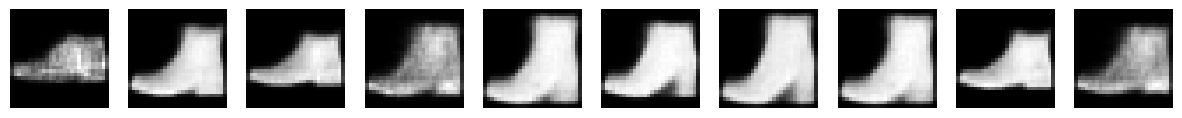

for label 9 with the new channel encoding.


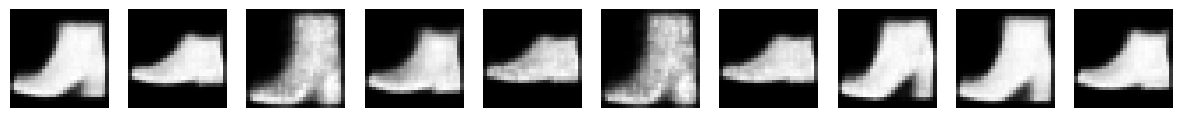

In [15]:

for i in range(0,10):
    print(f"for label {i} with the integer encoding model.")
    cvae_int.generate_sample(label=i)
    print(f"for label {i} with the onehot encoding.")
    cvae_onehot.generate_sample(label=i)
    print(f"for label {i} with the new channel encoding.")
    cvae_channel.generate_sample(label=i)

However, this is not a quantitative method for comparing the architectures

## 2.4 Validating hyperparameters: choice of hidden dimension.

testing

In [16]:
def train_one_epoch(model, dataloader, loss_function, optimizer, device):
    model.train()
    total_loss = 0

    for x, label in dataloader:
        x = x.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        reconstructed_x, mu, logvar = model(x, label)
        loss= loss_function(reconstructed_x, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader.dataset)


def validate_one_epoch(model, dataloader, loss_function ,device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, label in dataloader:
            x = x.to(device)
            label = label.to(device)

            reconstructed_x, mu, logvar = model(x, label)
            loss = loss_function(reconstructed_x, x, mu, logvar)

            total_loss += loss.item()

    return total_loss / len(dataloader.dataset)


In [17]:
from collections import defaultdict

def train_multiple_latent_dims(
    latent_dims,
    train_loader,
    val_loader,
    loss_function,
    device,
    epochs=20,
    lr=1e-3):
    
    results = {}

    for latent_dim in latent_dims:
        print(f"\nTraining model with latent_dim = {latent_dim}")

        model = ConditionalConvVAE_int_concatenation(
            latent_dim=latent_dim
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        history = defaultdict(list)

        for epoch in range(epochs):
            train_loss = train_one_epoch(
                model=model, dataloader=train_loader, loss_function=loss_function, optimizer=optimizer, device=device
            )
            val_loss = validate_one_epoch(
                model=model, dataloader=val_loader, loss_function=loss_function,device=device
            )

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)

            print(
                f"Epoch {epoch+1:03d} | "
                f"Train: {train_loss:.4f} | "
                f"Val: {val_loss:.4f}"
            )

        results[latent_dim] = {
            "model": model,
            "history": history
        }

    return results


Here we define a function that plots the test and validation losses for a given model, for a set of hyperparameters specified by the user.

In [18]:
from collections import defaultdict

def train_multiple_latent_dims(
    model_class,
    latent_dims,
    train_loader,
    val_loader,
    loss_function,
    device,
    epochs=20,
    lr=1e-3):
    
    results = {}

    for latent_dim in latent_dims:
        print(f"\nTraining model with latent_dim = {latent_dim}")

        model = model_class(
            latent_dim=latent_dim
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        history = defaultdict(list)

        for epoch in range(epochs):
            train_loss = train_one_epoch(
                model=model, dataloader=train_loader, loss_function=loss_function, optimizer=optimizer, device=device
            )
            val_loss = validate_one_epoch(
                model=model, dataloader=val_loader, loss_function=loss_function,device=device
            )

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)

            print(
                f"Epoch {epoch+1:03d} | "
                f"Train: {train_loss:.4f} | "
                f"Val: {val_loss:.4f}"
            )

        results[latent_dim] = {
            "model": model,
            "history": history
        }

    return results

Here we do this hyperparameter exploration for the channel model.


Training model with latent_dim = 2
Epoch 001 | Train: 274.7146 | Val: 259.0002
Epoch 002 | Train: 256.5117 | Val: 257.4415
Epoch 003 | Train: 254.8052 | Val: 256.2402
Epoch 004 | Train: 253.9236 | Val: 254.8186
Epoch 005 | Train: 253.1947 | Val: 256.6289
Epoch 006 | Train: 252.7749 | Val: 254.2548
Epoch 007 | Train: 252.3585 | Val: 253.8654
Epoch 008 | Train: 252.0905 | Val: 253.8621
Epoch 009 | Train: 251.7615 | Val: 253.0362
Epoch 010 | Train: 251.5037 | Val: 252.8490
Epoch 011 | Train: 251.2697 | Val: 252.7507
Epoch 012 | Train: 251.0855 | Val: 253.2319
Epoch 013 | Train: 250.9788 | Val: 253.5005
Epoch 014 | Train: 250.7387 | Val: 252.3399
Epoch 015 | Train: 250.5205 | Val: 252.2051
Epoch 016 | Train: 250.3961 | Val: 252.2671
Epoch 017 | Train: 250.2160 | Val: 252.7303
Epoch 018 | Train: 250.1120 | Val: 251.9168
Epoch 019 | Train: 250.0054 | Val: 252.3951
Epoch 020 | Train: 249.8436 | Val: 251.8932
Epoch 021 | Train: 249.7401 | Val: 251.5548
Epoch 022 | Train: 249.5634 | Val: 251.7

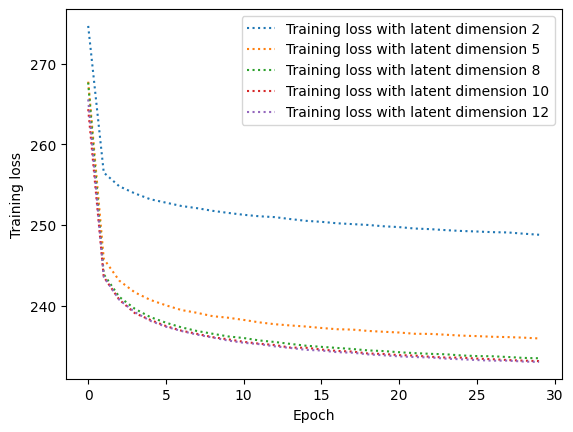

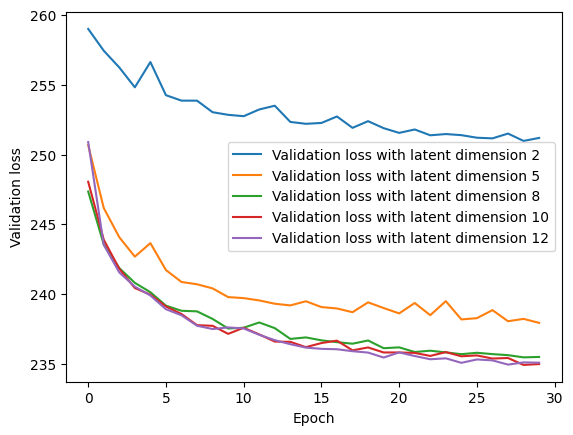

In [19]:

epochs=30

#Figure for training losses
plt.figure(0)

#Figure for validation losses
plt.figure(1)

results = train_multiple_latent_dims(
    model_class=ConditionalConvVAE_channel_concatenation,
    latent_dims=[2,5,8,10,12],
    train_loader=train_loader,
    val_loader=test_loader,
    loss_function=loss_function,
    device=device,
    epochs=epochs,
    lr=learning_rate
)

for latent_dim, data in results.items():

    plt.figure(0)
    plt.plot(
        data["history"]["train_loss"],
        label=f"Training loss with latent dimension {latent_dim}",
        linestyle=':'
    )
    plt.figure(1)
    plt.plot(
        data["history"]["val_loss"],
        label=f"Validation loss with latent dimension {latent_dim}"
    )

plt.figure(0)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Training loss")

plt.figure(1)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation loss")

plt.show()

Hyperparameter validation for the one-hot-encoded model


Training model with latent_dim = 2
Epoch 001 | Train: 273.4219 | Val: 259.0877
Epoch 002 | Train: 256.9400 | Val: 258.3451
Epoch 003 | Train: 255.2300 | Val: 256.2991
Epoch 004 | Train: 254.3596 | Val: 255.1668
Epoch 005 | Train: 253.7103 | Val: 254.8352
Epoch 006 | Train: 253.1636 | Val: 254.6246
Epoch 007 | Train: 252.7965 | Val: 254.1932
Epoch 008 | Train: 252.3164 | Val: 255.1171
Epoch 009 | Train: 251.9887 | Val: 253.5978
Epoch 010 | Train: 251.5873 | Val: 253.2013
Epoch 011 | Train: 251.4722 | Val: 253.3502
Epoch 012 | Train: 251.0575 | Val: 252.8372
Epoch 013 | Train: 250.7832 | Val: 252.7722
Epoch 014 | Train: 250.5369 | Val: 252.1633
Epoch 015 | Train: 250.2930 | Val: 252.4393
Epoch 016 | Train: 250.0615 | Val: 252.0639
Epoch 017 | Train: 249.8320 | Val: 251.8331
Epoch 018 | Train: 249.6842 | Val: 251.7269
Epoch 019 | Train: 249.4870 | Val: 251.2822
Epoch 020 | Train: 249.3239 | Val: 251.4924
Epoch 021 | Train: 249.1328 | Val: 251.7308
Epoch 022 | Train: 249.0212 | Val: 251.1

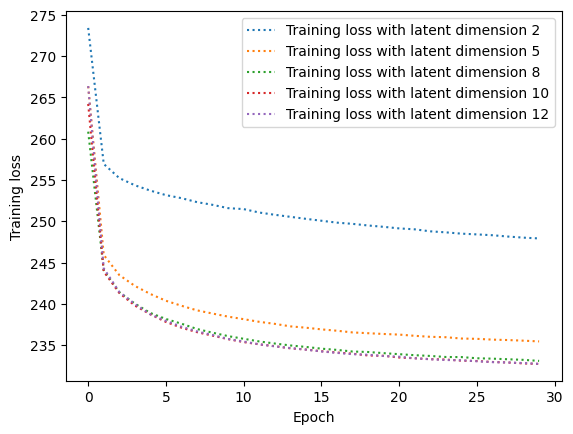

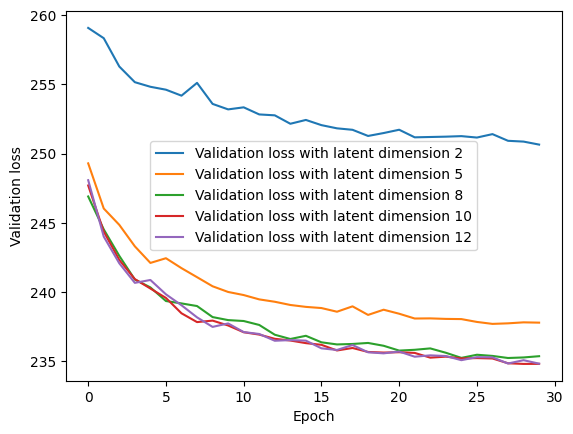

In [20]:

epochs=30

#Figure for training losses
plt.figure(0)

#Figure for validation losses
plt.figure(1)

results = train_multiple_latent_dims(
    model_class=ConditionalConvVAE_onehot_concatenation,
    latent_dims=[2,5,8,10,12],
    train_loader=train_loader,
    val_loader=test_loader,
    loss_function=loss_function,
    device=device,
    epochs=epochs,
    lr=learning_rate
)

for latent_dim, data in results.items():
    plt.figure(0)
    plt.plot(
        data["history"]["train_loss"],
        label=f"Training loss with latent dimension {latent_dim}",
        linestyle=':'
    )
    
    plt.figure(1)
    plt.plot(
        data["history"]["val_loss"],
        label=f"Validation loss with latent dimension {latent_dim}"
    )
plt.figure(0)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Training loss")

plt.figure(1)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation loss")

plt.show()


Given the results of the previous exploration, we wish to further fine-tune the hyper parameters further for both methods.

First for the one-hot-encoded method


Training model with latent_dim = 4
Epoch 001 | Train: 272.0972 | Val: 253.4403
Epoch 002 | Train: 248.3047 | Val: 249.3305
Epoch 003 | Train: 245.7951 | Val: 247.9531
Epoch 004 | Train: 244.5097 | Val: 245.5465
Epoch 005 | Train: 243.6176 | Val: 245.4977
Epoch 006 | Train: 242.8851 | Val: 244.8138
Epoch 007 | Train: 242.2915 | Val: 243.5119
Epoch 008 | Train: 241.7635 | Val: 243.2196
Epoch 009 | Train: 241.2050 | Val: 242.7615
Epoch 010 | Train: 240.8173 | Val: 242.5647
Epoch 011 | Train: 240.4847 | Val: 242.4214
Epoch 012 | Train: 240.1969 | Val: 242.3035
Epoch 013 | Train: 239.8868 | Val: 241.7441
Epoch 014 | Train: 239.5871 | Val: 241.7828
Epoch 015 | Train: 239.3692 | Val: 241.4633
Epoch 016 | Train: 239.2311 | Val: 241.4704
Epoch 017 | Train: 238.9732 | Val: 241.0929
Epoch 018 | Train: 238.8671 | Val: 241.5304
Epoch 019 | Train: 238.6981 | Val: 240.7235
Epoch 020 | Train: 238.5663 | Val: 240.9883
Epoch 021 | Train: 238.3795 | Val: 240.6818
Epoch 022 | Train: 238.3165 | Val: 240.3

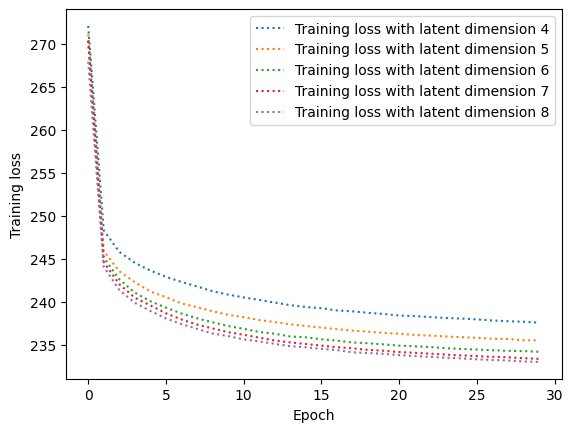

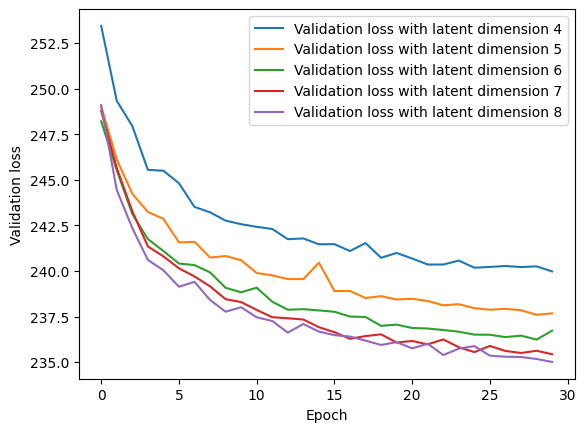

In [21]:

epochs=30

#Figure for training losses
plt.figure(0)

#Figure for validation losses
plt.figure(1)


results = train_multiple_latent_dims(
    model_class=ConditionalConvVAE_onehot_concatenation,
    latent_dims=[4,5,6,7,8],
    train_loader=train_loader,
    val_loader=test_loader,
    loss_function=loss_function,
    device=device,
    epochs=epochs,
    lr=learning_rate
)

for latent_dim, data in results.items():
    plt.figure(0)
    plt.plot(
        data["history"]["train_loss"],
        label=f"Training loss with latent dimension {latent_dim}",
        linestyle=':'
    )
    plt.figure(1)
    plt.plot(
        data["history"]["val_loss"],
        label=f"Validation loss with latent dimension {latent_dim}"
    )
    
plt.figure(0)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Training loss")

plt.figure(1)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation loss")

plt.show()

Then for the learn embeddings 


Training model with latent_dim = 4
Epoch 001 | Train: 265.2916 | Val: 252.7675
Epoch 002 | Train: 247.2822 | Val: 247.4190
Epoch 003 | Train: 245.0036 | Val: 245.3936
Epoch 004 | Train: 243.6620 | Val: 244.7814
Epoch 005 | Train: 242.7856 | Val: 244.0522
Epoch 006 | Train: 242.1123 | Val: 243.8709
Epoch 007 | Train: 241.6280 | Val: 244.4338
Epoch 008 | Train: 241.2356 | Val: 242.8769
Epoch 009 | Train: 240.6831 | Val: 242.3304
Epoch 010 | Train: 240.5688 | Val: 242.4193
Epoch 011 | Train: 240.2288 | Val: 242.1494
Epoch 012 | Train: 240.1215 | Val: 241.8270
Epoch 013 | Train: 239.8593 | Val: 241.7425
Epoch 014 | Train: 239.6863 | Val: 241.6364
Epoch 015 | Train: 239.5363 | Val: 242.3380
Epoch 016 | Train: 239.4223 | Val: 241.5164
Epoch 017 | Train: 239.2796 | Val: 241.2924
Epoch 018 | Train: 239.1616 | Val: 241.2074
Epoch 019 | Train: 239.0380 | Val: 241.2384
Epoch 020 | Train: 238.9025 | Val: 240.9485
Epoch 021 | Train: 238.8314 | Val: 240.8256
Epoch 022 | Train: 238.6622 | Val: 241.2

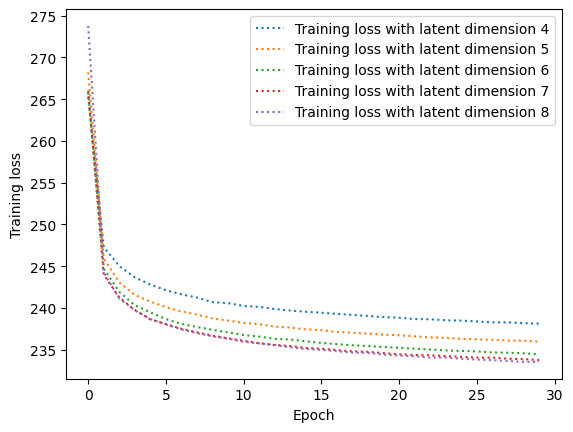

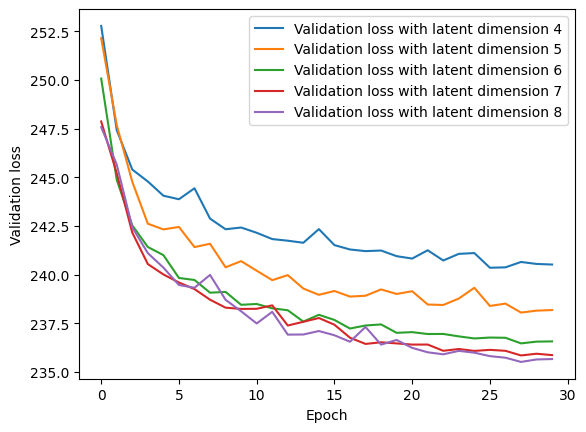

In [22]:
epochs=30

#Figure for training losses
plt.figure(0)

#Figure for validation losses
plt.figure(1)


results = train_multiple_latent_dims(
    model_class=ConditionalConvVAE_channel_concatenation,
    latent_dims=[4,5,6,7,8],
    train_loader=train_loader,
    val_loader=test_loader,
    loss_function=loss_function,
    device=device,
    epochs=epochs,
    lr=learning_rate
)

for latent_dim, data in results.items():
    plt.figure(0)
    plt.plot(
        data["history"]["train_loss"],
        label=f"Training loss with latent dimension {latent_dim}",
        linestyle=':'
    )
    plt.figure(1)
    plt.plot(
        data["history"]["val_loss"],
        label=f"Validation loss with latent dimension {latent_dim}"
    )
    
plt.figure(0)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Training loss")

plt.figure(1)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation loss")

plt.show()

## 3. Training the models specifically for image generation

In the above sections, we trained the models with a loss with a very small KL divergence hyperparameter $\alpha$, as our priotity was to minimize the image reconstruction loss. If we wish to use the decoder of these models for image generation, we must train them with larger values of $\alpha$, so the embedding space representation of the dataset resembles realisations of Gaussian distribution. This is so that the image generation procedure won't cause generation of nonsensical images created by the decoding of realisations in the embedding space that land in between data clusters.

Here we want more details on which of the terms of the loss is diminsihing, so we redefine the loss function.

In [23]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD

We will now test the behavior of the channel encodding model for different values of the KL divergence coefficient.


Training VAE with KL Weight = 1
Epoch 1: Average Loss: 265.0199, BCE: 253.7009, KLD: 11.3190
Epoch 2: Average Loss: 243.5940, BCE: 232.2233, KLD: 11.3707
Epoch 3: Average Loss: 240.6450, BCE: 229.3703, KLD: 11.2748
Epoch 4: Average Loss: 239.2842, BCE: 228.0193, KLD: 11.2649
Epoch 5: Average Loss: 238.2097, BCE: 226.9234, KLD: 11.2863
Epoch 6: Average Loss: 237.4897, BCE: 226.1370, KLD: 11.3527
Epoch 7: Average Loss: 236.8875, BCE: 225.5165, KLD: 11.3710
Epoch 8: Average Loss: 236.4800, BCE: 225.0739, KLD: 11.4061
Epoch 9: Average Loss: 236.1046, BCE: 224.6873, KLD: 11.4172
Epoch 10: Average Loss: 235.8420, BCE: 224.3944, KLD: 11.4476


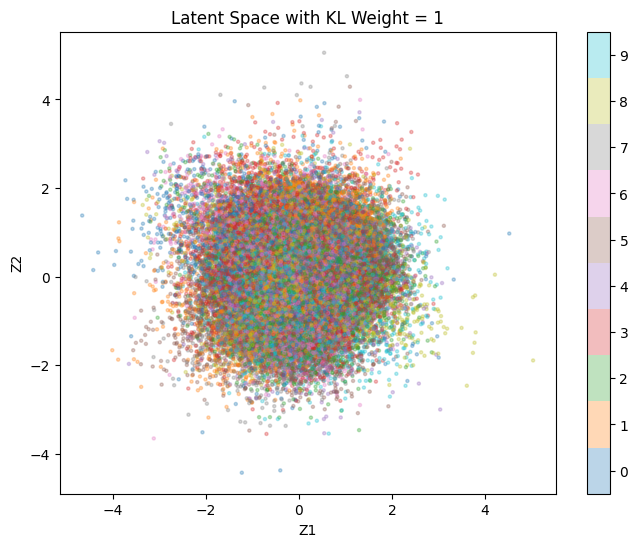


Training VAE with KL Weight = 5
Epoch 1: Average Loss: 289.6754, BCE: 272.9578, KLD: 3.3435
Epoch 2: Average Loss: 268.9489, BCE: 252.1292, KLD: 3.3639
Epoch 3: Average Loss: 266.8647, BCE: 249.4171, KLD: 3.4895
Epoch 4: Average Loss: 265.6500, BCE: 247.9232, KLD: 3.5454
Epoch 5: Average Loss: 264.8570, BCE: 246.8374, KLD: 3.6039
Epoch 6: Average Loss: 264.3644, BCE: 246.0547, KLD: 3.6619
Epoch 7: Average Loss: 263.6793, BCE: 245.3322, KLD: 3.6694
Epoch 8: Average Loss: 263.4118, BCE: 244.8361, KLD: 3.7151
Epoch 9: Average Loss: 262.9874, BCE: 244.4087, KLD: 3.7158
Epoch 10: Average Loss: 262.7793, BCE: 244.1130, KLD: 3.7333


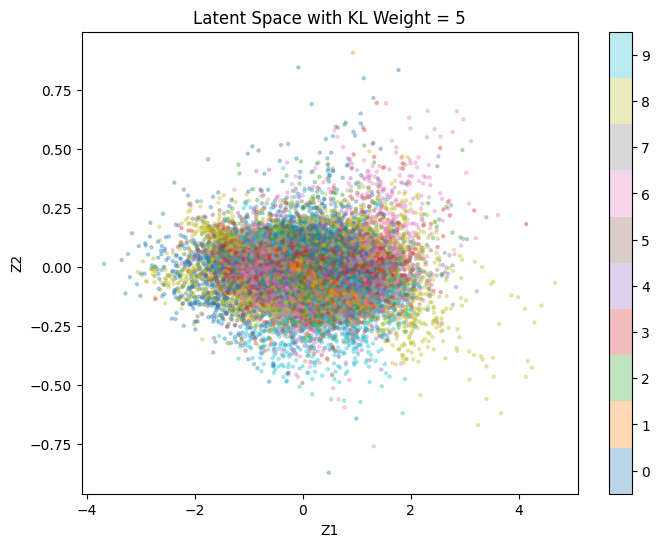


Training VAE with KL Weight = 10
Epoch 1: Average Loss: 303.4614, BCE: 286.7388, KLD: 1.6723
Epoch 2: Average Loss: 281.9678, BCE: 263.5032, KLD: 1.8465
Epoch 3: Average Loss: 280.1641, BCE: 260.9542, KLD: 1.9210
Epoch 4: Average Loss: 279.2814, BCE: 259.8618, KLD: 1.9420
Epoch 5: Average Loss: 278.6150, BCE: 258.9636, KLD: 1.9651
Epoch 6: Average Loss: 278.1650, BCE: 258.3196, KLD: 1.9845
Epoch 7: Average Loss: 277.8101, BCE: 257.8078, KLD: 2.0002
Epoch 8: Average Loss: 277.6062, BCE: 257.4938, KLD: 2.0112
Epoch 9: Average Loss: 277.2230, BCE: 257.1141, KLD: 2.0109
Epoch 10: Average Loss: 277.0385, BCE: 256.8398, KLD: 2.0199


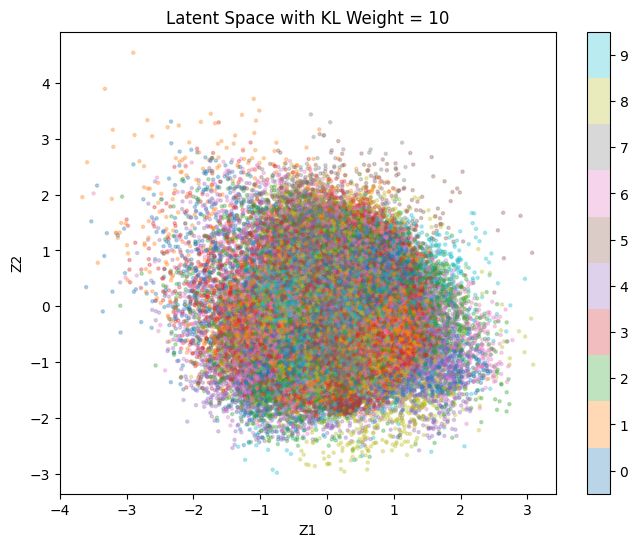


Training VAE with KL Weight = 50
Epoch 1: Average Loss: 325.2930, BCE: 320.3293, KLD: 0.0993
Epoch 2: Average Loss: 308.3100, BCE: 304.5583, KLD: 0.0750
Epoch 3: Average Loss: 307.3286, BCE: 301.5075, KLD: 0.1164
Epoch 4: Average Loss: 306.6318, BCE: 299.6080, KLD: 0.1405
Epoch 5: Average Loss: 306.5045, BCE: 298.7979, KLD: 0.1541
Epoch 6: Average Loss: 306.2562, BCE: 298.1086, KLD: 0.1630
Epoch 7: Average Loss: 306.0802, BCE: 297.5805, KLD: 0.1700
Epoch 8: Average Loss: 305.6668, BCE: 297.3606, KLD: 0.1661
Epoch 9: Average Loss: 305.8370, BCE: 297.3593, KLD: 0.1696
Epoch 10: Average Loss: 305.8324, BCE: 297.3361, KLD: 0.1699


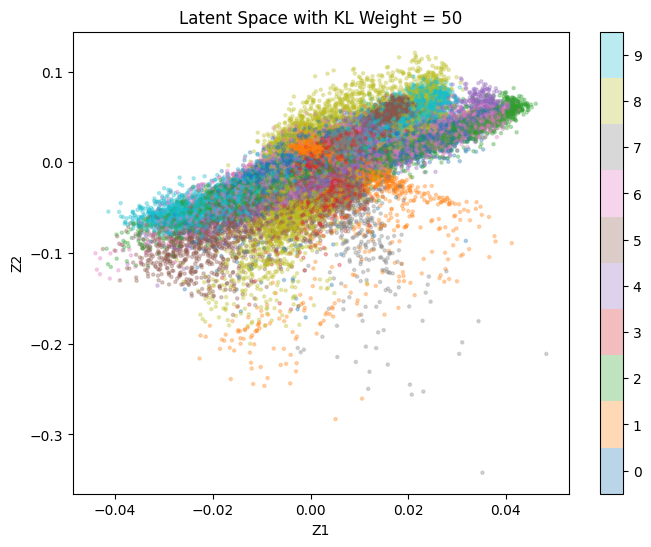


Training VAE with KL Weight = 100
Epoch 1: Average Loss: 333.1850, BCE: 326.5456, KLD: 0.0664
Epoch 2: Average Loss: 308.7425, BCE: 308.3390, KLD: 0.0040
Epoch 3: Average Loss: 308.2753, BCE: 307.9715, KLD: 0.0030
Epoch 4: Average Loss: 308.0709, BCE: 307.7489, KLD: 0.0032
Epoch 5: Average Loss: 307.9527, BCE: 307.6874, KLD: 0.0027
Epoch 6: Average Loss: 307.8398, BCE: 307.5535, KLD: 0.0029
Epoch 7: Average Loss: 307.7806, BCE: 307.5549, KLD: 0.0023
Epoch 8: Average Loss: 307.6916, BCE: 307.5164, KLD: 0.0018
Epoch 9: Average Loss: 307.6764, BCE: 307.5098, KLD: 0.0017
Epoch 10: Average Loss: 307.5909, BCE: 307.4632, KLD: 0.0013


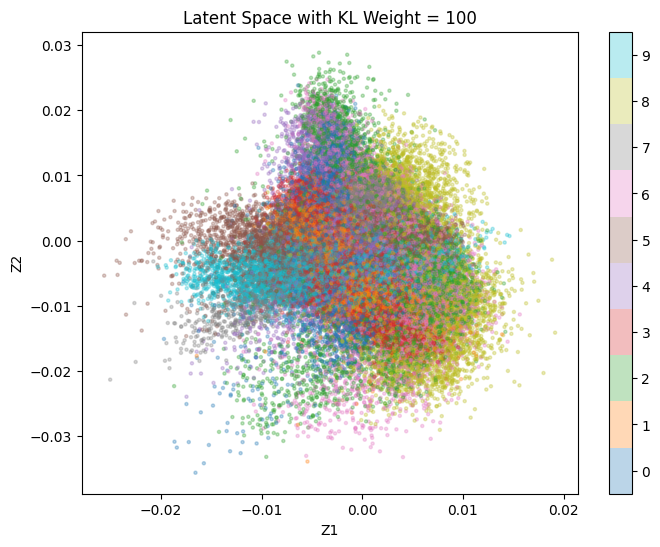

In [ ]:
# Hyperparameters
latent_dims = 8
batch_size = 128
num_epochs = 10
learning_rate = 1e-3
kl_weights = [1, 5, 10, 50, 100]  # Different weights for the KL divergence term


# Training and plotting function
def train_and_plot(model_class,latent_dims, num_epochs, learning_rate, kl_weight):
    model = model_class(latent_dims).to(device)
    assert model_class == ConditionalConvVAE_channel_concatenation #otherwise it doesn't work
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        bce_loss = 0
        kld_loss = 0
        for batch_idx, (data, label) in enumerate(train_loader):
            data = data.to(device)
            label = label.to(device)

            optimizer.zero_grad()
            x_recon, mu, logvar = model(data,label)
            loss, bce, kld = loss_function(x_recon, data, mu, logvar, kl_weight)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            bce_loss += bce.item()
            kld_loss += kld.item()
        
        average_loss = epoch_loss / len(train_loader.dataset)
        average_bce = bce_loss / len(train_loader.dataset)
        average_kld = kld_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}: Average Loss: {average_loss:.4f}, BCE: {average_bce:.4f}, KLD: {average_kld:.4f}')
    
    # Plot latent space
    plot_latent_space(model=model, data_loader=train_loader, kl_weight=kl_weight)

# Function to plot latent space


def plot_latent_space(model, data_loader, kl_weight):
    model.eval()

    zs = []
    all_labels = []

    with torch.no_grad():
        for data, labels in data_loader:
            data = data.to(device)
            labels = labels.to(device)

            label_map = model.make_label_map(label=labels)
            mu, logvar = model.encode(data, label_map=label_map)

            zs.append(mu.cpu())
            all_labels.append(labels.cpu())

    z = torch.cat(zs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        z[:, 0], z[:, 1],
        c=labels,
        cmap='tab10',
        alpha=0.3,        # lower alpha helps with density
        s=5               # smaller points = clearer structure
    )
    plt.colorbar(scatter, ticks=range(10))
    plt.clim(-0.5, 9.5)
    plt.title(f'Latent Space with KL Weight = {kl_weight}')
    plt.xlabel('Z1')
    plt.ylabel('Z2')
    plt.show()

# Run training and plotting for different KL weights
for kl_weight in kl_weights:
    print(f'\nTraining VAE with KL Weight = {kl_weight}')
    train_and_plot(model_class=ConditionalConvVAE_channel_concatenation, latent_dims=latent_dims, num_epochs=num_epochs, learning_rate=learning_rate, kl_weight=kl_weight)


The previous even for small alpha, the KL divergence is minuscule. This is because the label being inserted at encoding and decoding makes it is not necessary to have latent space representations that discriminate among different classes in the latent space. Hence even with small alpha, the KL divergence is minuscule. These conclusions can also be found for a similar model described in [6]. The CVAE can focus on intra-class variation, and does not need to distinguish the embedding coordinates for different labels.

This shows us that the KL divergence term is not even necessary for CVAE training with image-generation intentions.

## Conclusion

In this report we studied three possible architectures of CVAE: one trivialy awful, one relying on post-convolution conditioning onto linear layers, and one involving pre-encoding conditioning without image distortion. After analyzing different choices hyperparameters, we concluded that a hidden dimension above 8 has no advantage over one above 12. Surprinsingly enough, the models with hidden dimension of 12 did not show signs of overtraining, but this is understandable because of the randomness involved in the latent state. We then, in order to implement models with good image generation, studied the geometry of the latent space for different loss function, and noticed that even loss functions with low KL-divergence terms result in latent spaces resembling realisations of Gaussian vectors. This was a result already discussed in the litterature, and is due to the explicit conditioning avoiding the need for separating classes in the embedding space. 

Hence, CVAEs appear to be excelent models for conditional image generation. Nonetheless further comparisons between architectures should be made, as it is not evident that an unconditionally dominating one exists. This should also be done for different data sets, as the probability distribution underlying the data set could affect the behaviour of the data as it goes through the layers.

# References


[1]: Joseba Dalmau, Juliette Chevalier and David Bertoin: High-dimensional and Deep Learning. Course for 5th year of engineering in applied mathematics, National Institute of Applied sciences of Toulouse (INSA Toulouse), 2025

[2]: DP Kingma, M Welling: Auto-Encoding Variational Bayes. arxiv preprint:1312.6114, 2013

[3] : DP Kingma, DJ Rezende, S Mohamed, M Welling: Semi-supervised Learning with Deep Generative Models. Advances in Neural Information Processing systems 2014

[4] : debtanu177. (2021). train_cvae.py [Computer software]. GitHub. https://github.com/debtanu177/CVAE_MNIST/blob/master/train_cvae.py

[5] : Xiao, Han, et. al. "Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms." arXiv:2403.15378 (2024) (MIT license).

[6] : Ryan D'Cunha.  "Conditional Variational Autoencoders for text to Image Generation", towardsdatascience.com.